## Step 1: Load Cleaned Data + Stage Labels (FD001)


---

### Step 1A: Load FD001 clustered data


In [1]:
# ✅ Step 1A: Load FD001 clustered data
import pandas as pd
import numpy as np
import os

# Set base directory
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_FILE = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_FD001.csv')

# Load the clustered dataset
df = pd.read_csv(DATA_FILE)
print("✅ Loaded:", DATA_FILE)
print(df.head())


✅ Loaded: c:\Users\pandr\hybrid-predictive-maintenance\data\corrected_clustered_train_FD001.csv
   unit  time  op_setting_1  op_setting_2  op_setting_3  sensor_2  sensor_3  \
0     1     1       -0.0007       -0.0004         100.0  0.183735  0.406802   
1     1     2        0.0019       -0.0003         100.0  0.283133  0.453019   
2     1     3       -0.0043        0.0003         100.0  0.343373  0.369523   
3     1     4        0.0007        0.0000         100.0  0.343373  0.256159   
4     1     5       -0.0019       -0.0002         100.0  0.349398  0.257467   

   sensor_4  sensor_6  sensor_7  ...  sensor_17  sensor_20  sensor_21  \
0  0.309757       1.0  0.726248  ...   0.333333   0.713178   0.724662   
1  0.352633       1.0  0.628019  ...   0.333333   0.666667   0.731014   
2  0.370527       1.0  0.710145  ...   0.166667   0.627907   0.621375   
3  0.331195       1.0  0.740741  ...   0.333333   0.573643   0.662386   
4  0.404625       1.0  0.668277  ...   0.416667   0.589147   0.7

### Step 1B: Sort by engine and time


In [2]:
# ✅ Step 1B: Sort by engine and time
df = df.sort_values(by=['unit', 'time']).reset_index(drop=True)
print("✅ Sorted by 'unit' and 'time'")


✅ Sorted by 'unit' and 'time'


### Step 1C: Initialize regression target column


In [3]:
# ✅ Step 1C: Initialize regression target column
df['cycles_to_next_stage'] = np.nan
print("✅ Initialized column: cycles_to_next_stage")


✅ Initialized column: cycles_to_next_stage


### Step 1D: Core logic – compute cycles to next stage


In [4]:
# ✅ Step 1D: Core logic — compute cycles to next degradation stage
engine_ids = df['unit'].unique()

for engine_id in engine_ids:
    engine_df = df[df['unit'] == engine_id]
    indices = engine_df.index.tolist()
    stages = engine_df['final_stage'].tolist()
    times = engine_df['time'].tolist()

    for i in range(len(indices)):
        current_stage = stages[i]
        current_time = times[i]
        found = False
        for j in range(i + 1, len(indices)):
            if stages[j] != current_stage:
                next_time = times[j]
                df.loc[indices[i], 'cycles_to_next_stage'] = next_time - current_time
                found = True
                break
        if not found:
            df.loc[indices[i], 'cycles_to_next_stage'] = np.nan
print("✅ Cycles to next stage computed for all engines")


✅ Cycles to next stage computed for all engines


### Step 1E: Inspect results


In [5]:
# ✅ Step 1E: Inspect results
print("\n🔍 Sample output with 'cycles_to_next_stage':")
print(df[['unit', 'time', 'final_stage', 'cycles_to_next_stage']].head(20))



🔍 Sample output with 'cycles_to_next_stage':
    unit  time  final_stage  cycles_to_next_stage
0      1     1            4                  12.0
1      1     2            4                  11.0
2      1     3            4                  10.0
3      1     4            4                   9.0
4      1     5            4                   8.0
5      1     6            4                   7.0
6      1     7            4                   6.0
7      1     8            4                   5.0
8      1     9            4                   4.0
9      1    10            4                   3.0
10     1    11            4                   2.0
11     1    12            4                   1.0
12     1    13            3                   1.0
13     1    14            4                   3.0
14     1    15            4                   2.0
15     1    16            4                   1.0
16     1    17            3                   1.0
17     1    18            4                   4.0
18  

### Step 1F: Save the enriched dataset


In [6]:
# ✅ Step 1F: Save enriched dataset
output_path = os.path.join(BASE_DIR, 'data', 'regression_train_FD001.csv')
df.to_csv(output_path, index=False)
print(f"✅ Saved to: {output_path}")


✅ Saved to: c:\Users\pandr\hybrid-predictive-maintenance\data\regression_train_FD001.csv


### Step: Sanity check


In [7]:
# ✅ Step 1G: Final sanity check
print("\n📊 Summary:")
print("Total rows       :", len(df))
print("Missing Targets  :", df['cycles_to_next_stage'].isna().sum())
print("Unique engines   :", df['unit'].nunique())



📊 Summary:
Total rows       : 20631
Missing Targets  : 2603
Unique engines   : 100


---

## Step 2: Train-Test Split (FD001)



---

### Step 2A: Load Regression-Labeled Data


In [8]:
import pandas as pd
import os

# Define base path
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_FILE = os.path.join(BASE_DIR, 'data', 'regression_train_FD001.csv')

# Load regression-labeled dataset
df = pd.read_csv(DATA_FILE)

# Drop rows where regression target is missing
df = df.dropna(subset=['cycles_to_next_stage']).reset_index(drop=True)

print(f"✅ Loaded FD001 regression dataset: {df.shape}")
print(df[['unit', 'time', 'final_stage', 'cycles_to_next_stage']].head())


✅ Loaded FD001 regression dataset: (18028, 28)
   unit  time  final_stage  cycles_to_next_stage
0     1     1            4                  12.0
1     1     2            4                  11.0
2     1     3            4                  10.0
3     1     4            4                   9.0
4     1     5            4                   8.0


### Step 2B: Define Features and Target


In [9]:
# Use all usable sensor columns
sensor_features = [col for col in df.columns if col.startswith('sensor_')]
target_col = 'cycles_to_next_stage'

X = df[sensor_features]
y = df[target_col]

print(f"✅ Using {len(sensor_features)} sensors: {sensor_features}")
print("🔹 Feature matrix shape:", X.shape)
print("🔹 Target shape:", y.shape)


✅ Using 15 sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
🔹 Feature matrix shape: (18028, 15)
🔹 Target shape: (18028,)


### Step 2C: Stratified Train-Test Split by Engine ID


In [10]:
from sklearn.model_selection import train_test_split

# Identify all unique engines
units = df['unit'].unique()

# Split engines (80% train, 20% test)
train_units, test_units = train_test_split(units, test_size=0.2, random_state=42)

# Filter full train and test data
train_df = df[df['unit'].isin(train_units)].reset_index(drop=True)
test_df = df[df['unit'].isin(test_units)].reset_index(drop=True)

# Final input and target arrays
X_train = train_df[sensor_features]
y_train = train_df[target_col]
X_test = test_df[sensor_features]
y_test = test_df[target_col]

print(f"✅ Train shape: {X_train.shape} | Test shape: {X_test.shape}")


✅ Train shape: (14490, 15) | Test shape: (3538, 15)


### Step: Sanity Check


In [11]:
print("🔍 Train engine count:", train_df['unit'].nunique())
print("🔍 Test engine count :", test_df['unit'].nunique())
print("🔍 Train class target preview:\n", y_train.describe())


🔍 Train engine count: 80
🔍 Test engine count : 20
🔍 Train class target preview:
 count    14490.000000
mean        16.319807
std         23.374005
min          1.000000
25%          2.000000
50%          6.000000
75%         20.000000
max        148.000000
Name: cycles_to_next_stage, dtype: float64


---
# Step 3: Model 1 – Random Forest Regressor with Full Evaluation (FD001)




### Step 3A: Import Libraries


In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os


### Step 3B: Initialize + Train Model


In [13]:
# Initialize Random Forest Regressor
rf_regressor = RandomForestRegressor(
    n_estimators=150,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_regressor.fit(X_train, y_train)


RandomForestRegressor(max_depth=12, n_estimators=150, n_jobs=-1,
                      random_state=42)

### Step 3C: Predict + Evaluate


In [14]:
# Predict on test data
y_pred_rf = rf_regressor.predict(X_test)

# Evaluate metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(" Random Forest Evaluation Metrics (FD001):")
print(f" RMSE: {rmse_rf:.2f}")
print(f" MAE : {mae_rf:.2f}")
print(f" R²  : {r2_rf:.4f}")


 Random Forest Evaluation Metrics (FD001):
 RMSE: 18.22
 MAE : 12.47
 R²  : 0.5250


#### Step 3C-1 – Cross-Validation Evaluation 

In [15]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rmse = -cross_val_score(rf_regressor, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error')
cv_mae  = -cross_val_score(rf_regressor, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
cv_r2   = cross_val_score(rf_regressor, X_train, y_train, cv=cv, scoring='r2')

print("\nCross-Validation Evaluation (Random Forest – FD001):")
print(f"CV RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")
print(f"CV MAE : {cv_mae.mean():.2f} ± {cv_mae.std():.2f}")
print(f"CV R²  : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")



Cross-Validation Evaluation (Random Forest – FD001):
CV RMSE: 16.75 ± 0.48
CV MAE : 11.61 ± 0.27
CV R²  : 0.4860 ± 0.0160


### Step 3D: Prediction vs Actual Visualization


✅ Saved prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\rf_pred_vs_actual_fd001.png


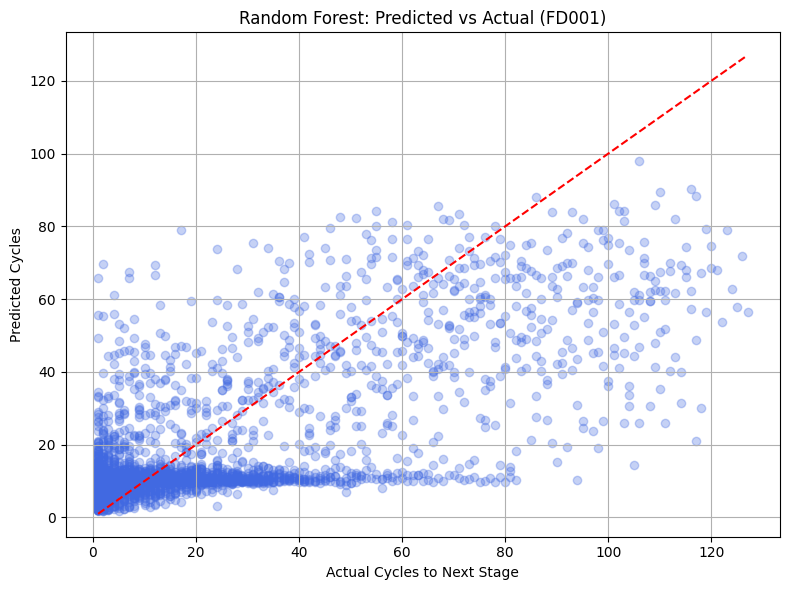

In [16]:
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'rf_pred_vs_actual_fd001.png'))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title("Random Forest: Predicted vs Actual (FD001)")
plt.grid(True)
plt.tight_layout()
plt.savefig(fig_path)
print(f"✅ Saved prediction plot to: {fig_path}")
plt.show()


### Step 3E: Save the Trained Model


In [17]:
model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'rf_regressor_fd001.pkl'))
joblib.dump(rf_regressor, model_path)
print(f"✅ Model saved to: {model_path}")


✅ Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\rf_regressor_fd001.pkl


### Step: Feature Importance Plot (For Interpretability)


✅ Feature importance plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\rf_feature_importance_fd001.png


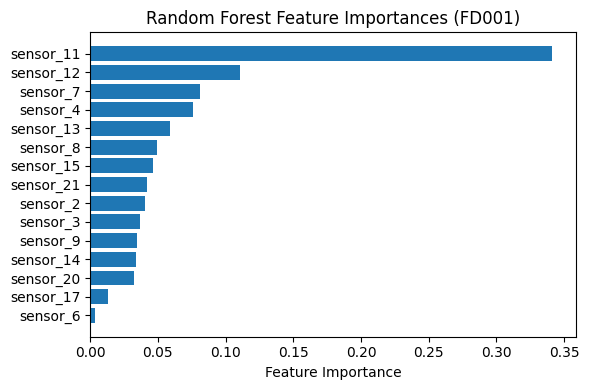

In [18]:
importances = rf_regressor.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(6, 4))
plt.barh(range(len(sensor_features)), [importances[i] for i in sorted_idx], align='center')
plt.yticks(range(len(sensor_features)), [sensor_features[i] for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances (FD001)")
plt.tight_layout()

feat_imp_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'rf_feature_importance_fd001.png'))
plt.savefig(feat_imp_path)
print(f"✅ Feature importance plot saved to: {feat_imp_path}")
plt.show()


---
# Step 4: Model 2 – Ridge Regression with Evaluation (FD001)

### Step 4A: Import Libraries


In [19]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os


### Step 4B: Initialize + Train Ridge Model


In [20]:
ridge_regressor = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0, random_state=42)
)

ridge_regressor.fit(X_train, y_train)
print("✅ Ridge model trained on all sensors.")


✅ Ridge model trained on all sensors.


### Step 4C: Predict + Evaluate


In [21]:
y_pred_ridge = ridge_regressor.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(" Ridge Regression Evaluation Metrics (FD001):")
print(f" RMSE: {rmse_ridge:.2f}")
print(f" MAE : {mae_ridge:.2f}")
print(f" R²  : {r2_ridge:.4f}")


 Ridge Regression Evaluation Metrics (FD001):
 RMSE: 22.76
 MAE : 16.24
 R²  : 0.2592


#### Step 4C-1 Cross Validation Evaluation

In [22]:
ridge_cv_pipeline = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0, random_state=42)
)

cv_rmse = -cross_val_score(ridge_cv_pipeline, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_mae = -cross_val_score(ridge_cv_pipeline, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
cv_r2 = cross_val_score(ridge_cv_pipeline, X_train, y_train, cv=5, scoring='r2')

print("\nCross-Validation Evaluation (Ridge Regression – FD001):")
print(f"CV RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")
print(f"CV MAE : {cv_mae.mean():.2f} ± {cv_mae.std():.2f}")
print(f"CV R²  : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")



Cross-Validation Evaluation (Ridge Regression – FD001):
CV RMSE: 20.74 ± 2.55
CV MAE : 15.46 ± 1.22
CV R²  : 0.1503 ± 0.1712


### Step 4D: Prediction vs Actual Visualization


✅ Prediction plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\ridge_pred_vs_actual_fd001.png


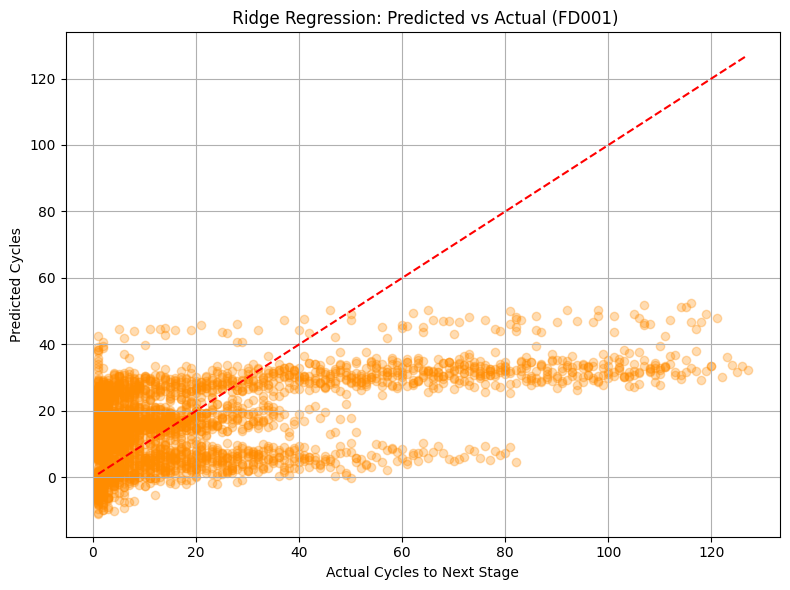

In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ridge, alpha=0.3, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title(" Ridge Regression: Predicted vs Actual (FD001)")
plt.grid(True)
plt.tight_layout()

ridge_fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'ridge_pred_vs_actual_fd001.png'))
plt.savefig(ridge_fig_path)
print(f"✅ Prediction plot saved to: {ridge_fig_path}")
plt.show()


### Step 4E: Save the Trained Ridge Model


In [24]:
ridge_model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'ridge_regressor_fd001.pkl'))
joblib.dump(ridge_regressor, ridge_model_path)
print(f"✅ Ridge model saved to: {ridge_model_path}")


✅ Ridge model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\ridge_regressor_fd001.pkl


### Step 4F: Feature Importance Plot (For Interpretability)


✅ Feature coefficient plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\ridge_feature_coefficients_fd001.png


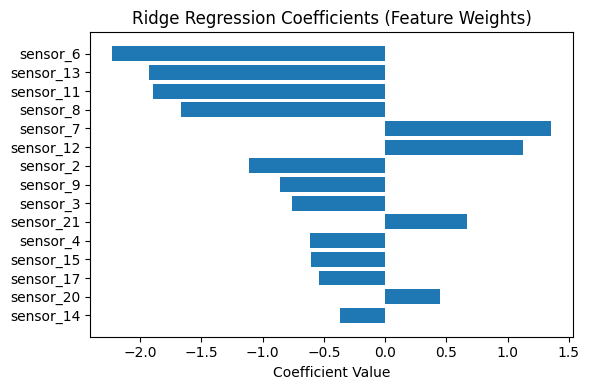

In [25]:
# Step 4F: Feature Importance Plot (For Interpretability) — FIXED

import matplotlib.pyplot as plt
import numpy as np
import os

# ✅ Define full sensor list (used for training)
selected_features = [
    'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7',
    'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13',
    'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21'
]

# ✅ Extract coefficients from ridge pipeline
ridge_coefficients = ridge_regressor.named_steps['ridge'].coef_
sorted_idx = np.argsort(np.abs(ridge_coefficients))

# ✅ Plot
plt.figure(figsize=(6, 4))
plt.barh(range(len(selected_features)), [ridge_coefficients[i] for i in sorted_idx], align='center')
plt.yticks(range(len(selected_features)), [selected_features[i] for i in sorted_idx])
plt.xlabel("Coefficient Value")
plt.title("Ridge Regression Coefficients (Feature Weights)")
plt.tight_layout()

# ✅ Save
ridge_coef_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'ridge_feature_coefficients_fd001.png'))
plt.savefig(ridge_coef_path)
print(f"✅ Feature coefficient plot saved to: {ridge_coef_path}")
plt.show()


---
## Step 5: Model 3 – Support Vector Regressor (SVR) Evaluation (FD001)




 SVR Evaluation Metrics (FD001):
 RMSE: 19.13
 MAE : 11.47
 R²  : 0.4766

Cross-Validation Evaluation (SVR – FD001):
CV RMSE: 17.23 ± 3.01
CV MAE : 10.43 ± 1.69
CV R²  : 0.4232 ± 0.1080
Saved prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\svr_pred_vs_actual_fd001.png


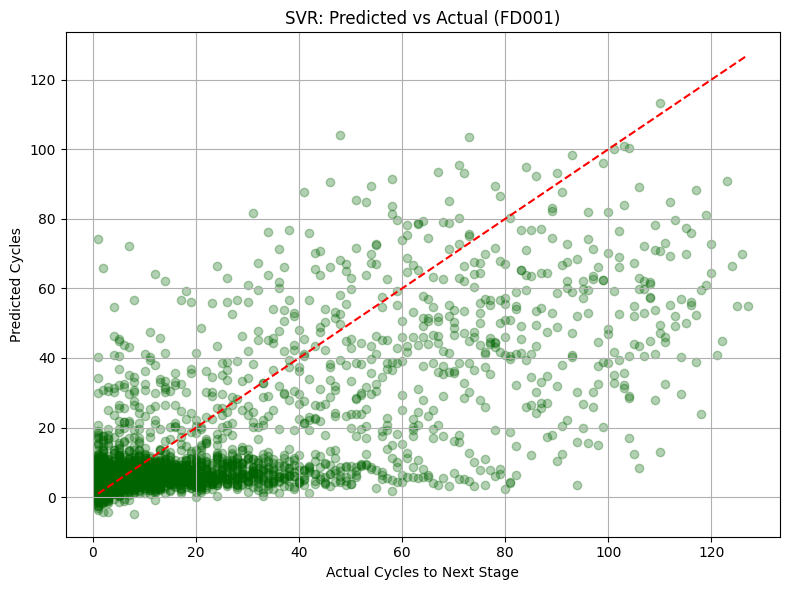

Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\svr_regressor_fd001.pkl
SVR does not expose feature importances or coefficients.


In [26]:
# --- Step 5: SVR Regressor (FD001) - Fixed for all sensors ---

from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os

# Create SVR pipeline
svr_regressor = make_pipeline(
    StandardScaler(),
    SVR(kernel='rbf', C=10.0, epsilon=0.2)
)

# Train
svr_regressor.fit(X_train, y_train)

# Predict
y_pred_svr = svr_regressor.predict(X_test)

# Metrics
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print(" SVR Evaluation Metrics (FD001):")
print(f" RMSE: {rmse_svr:.2f}")
print(f" MAE : {mae_svr:.2f}")
print(f" R²  : {r2_svr:.4f}")

# Cross-validation
svr_pipeline = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=10.0, epsilon=0.2))
cv_rmse = -cross_val_score(svr_pipeline, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_mae = -cross_val_score(svr_pipeline, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
cv_r2 = cross_val_score(svr_pipeline, X_train, y_train, cv=5, scoring='r2')

print("\nCross-Validation Evaluation (SVR – FD001):")
print(f"CV RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")
print(f"CV MAE : {cv_mae.mean():.2f} ± {cv_mae.std():.2f}")
print(f"CV R²  : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

# Plot: Prediction vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_svr, alpha=0.3, color='darkgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title("SVR: Predicted vs Actual (FD001)")
plt.grid(True)
plt.tight_layout()
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'svr_pred_vs_actual_fd001.png'))
plt.savefig(fig_path)
print(f"Saved prediction plot to: {fig_path}")
plt.show()

# Save model
model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'svr_regressor_fd001.pkl'))
joblib.dump(svr_regressor, model_path)
print(f"Model saved to: {model_path}")

print("SVR does not expose feature importances or coefficients.")


---
## Step 6: Model 4 – XGBoost Regressor with Evaluation (FD001)


 XGBoost Evaluation Metrics (FD001):
 RMSE: 18.49
 MAE : 12.41
 R²  : 0.5110

Cross-Validation Evaluation (XGBoost – FD001):
CV RMSE: 17.36 ± 2.20
CV MAE : 11.88 ± 1.13
CV R²  : 0.4005 ± 0.1351
Saved prediction plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\xgb_pred_vs_actual_fd001.png


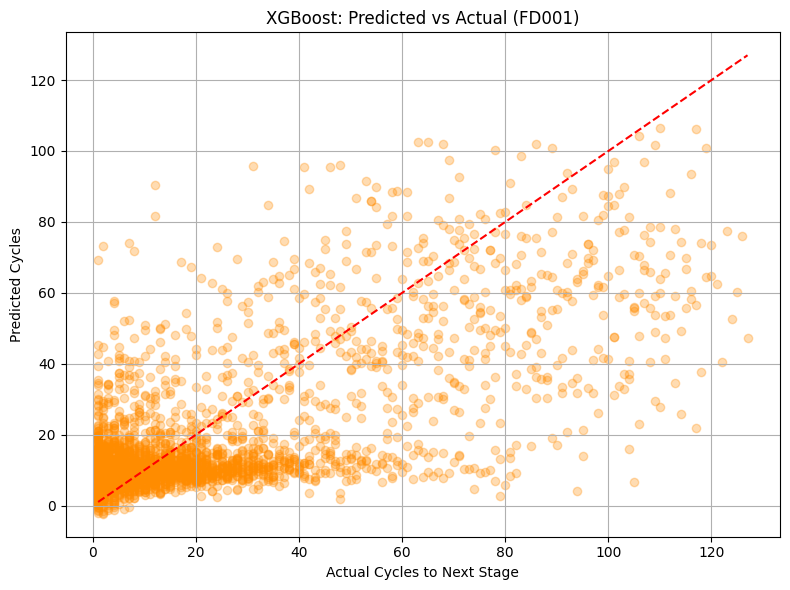

Model saved to: c:\Users\pandr\hybrid-predictive-maintenance\models\phase4\xgb_regressor_fd001.pkl
Feature importance plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\xgb_feature_importance_fd001.png


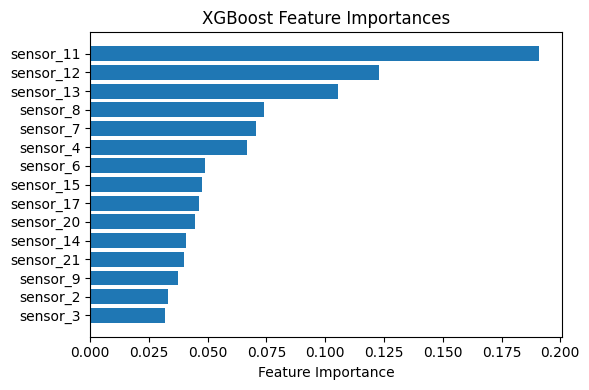

In [27]:
# --- Step 6: XGBoost Regressor (FD001) - Fixed for all sensors ---

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os

# Initialize
xgb_regressor = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

# Train
xgb_regressor.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_regressor.predict(X_test)

# Evaluate
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(" XGBoost Evaluation Metrics (FD001):")
print(f" RMSE: {rmse_xgb:.2f}")
print(f" MAE : {mae_xgb:.2f}")
print(f" R²  : {r2_xgb:.4f}")

# Cross-validation
xgb_cv = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

cv_rmse = -cross_val_score(xgb_cv, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
cv_mae = -cross_val_score(xgb_cv, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
cv_r2 = cross_val_score(xgb_cv, X_train, y_train, cv=5, scoring='r2')

print("\nCross-Validation Evaluation (XGBoost – FD001):")
print(f"CV RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")
print(f"CV MAE : {cv_mae.mean():.2f} ± {cv_mae.std():.2f}")
print(f"CV R²  : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

# Plot prediction vs actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.3, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles")
plt.title("XGBoost: Predicted vs Actual (FD001)")
plt.grid(True)
plt.tight_layout()
fig_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'xgb_pred_vs_actual_fd001.png'))
plt.savefig(fig_path)
print(f"Saved prediction plot to: {fig_path}")
plt.show()

# Save model
model_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'models', 'phase4', 'xgb_regressor_fd001.pkl'))
joblib.dump(xgb_regressor, model_path)
print(f"Model saved to: {model_path}")

# Feature importance
importances = xgb_regressor.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(6, 4))
plt.barh(range(len(selected_features)), [importances[i] for i in sorted_idx], align='center')
plt.yticks(range(len(selected_features)), [selected_features[i] for i in sorted_idx])
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importances")
plt.tight_layout()

# Save
feat_imp_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4', 'xgb_feature_importance_fd001.png'))
plt.savefig(feat_imp_path)
print(f"Feature importance plot saved to: {feat_imp_path}")
plt.show()


---
## Step 7: Model Comparison Summary (FD001)


### Step 7A: Define Model Results


In [28]:
# ✅ Step 7A: Save CV Comparison Table (FD001 – All Sensors)

import pandas as pd
import os

# Define cross-validation metrics (mean values) for all regressors – based on all sensors
model_results = pd.DataFrame({
    'Model': [
        'Random Forest',
        'Ridge Regression',
        'Support Vector Regressor',
        'XGBoost Regressor'
    ],
    'CV RMSE (Mean)': [16.75, 20.74, 17.23, 17.36],
    'CV MAE (Mean)':  [11.61, 15.46, 10.43, 11.88],
    'CV R² (Mean)':   [0.4860, 0.1503, 0.4232, 0.4005],
    'CV RMSE (± Std)': [0.48, 2.55, 3.01, 2.20],
    'CV MAE (± Std)':  [0.27, 1.22, 1.69, 1.13],
    'CV R² (± Std)':   [0.0160, 0.1712, 0.1080, 0.1351]
})

# Sort by RMSE ascending
model_results = model_results.sort_values(by='CV RMSE (Mean)').reset_index(drop=True)

# Save to report folder
report_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'report', 'phase4'))
os.makedirs(report_dir, exist_ok=True)
save_path = os.path.join(report_dir, 'model_comparison_cv_fd001.csv')
model_results.to_csv(save_path, index=False)

# Output
print(f"✅ CV model comparison table saved to: {save_path}")
print(model_results)


✅ CV model comparison table saved to: c:\Users\pandr\hybrid-predictive-maintenance\report\phase4\model_comparison_cv_fd001.csv
                      Model  CV RMSE (Mean)  CV MAE (Mean)  CV R² (Mean)  \
0             Random Forest           16.75          11.61        0.4860   
1  Support Vector Regressor           17.23          10.43        0.4232   
2         XGBoost Regressor           17.36          11.88        0.4005   
3          Ridge Regression           20.74          15.46        0.1503   

   CV RMSE (± Std)  CV MAE (± Std)  CV R² (± Std)  
0             0.48            0.27         0.0160  
1             3.01            1.69         0.1080  
2             2.20            1.13         0.1351  
3             2.55            1.22         0.1712  


### Step 7B: Plot Comparison Bar Chart



✅ Model comparison chart saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\model_comparison_cv_rmse_fd001.png


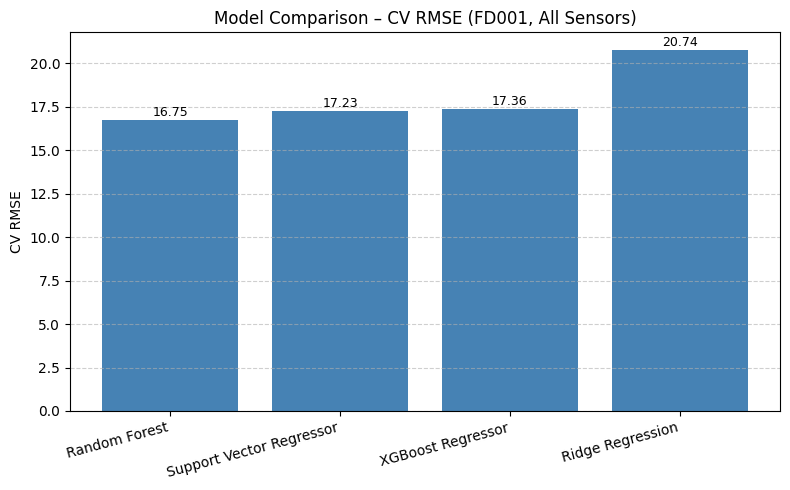

In [29]:
# ✅ Bar Plot for CV RMSE (All Sensors – FD001)

import matplotlib.pyplot as plt
import numpy as np
import os

# Load model_results if not already in memory
import pandas as pd
report_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'report', 'phase4'))
model_results_path = os.path.join(report_dir, 'model_comparison_cv_fd001.csv')
model_results = pd.read_csv(model_results_path)

# Bar Plot for CV RMSE
plt.figure(figsize=(8, 5))
bars = plt.bar(model_results['Model'], model_results['CV RMSE (Mean)'], color='steelblue')
plt.title("Model Comparison – CV RMSE (FD001, All Sensors)")
plt.ylabel("CV RMSE")
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

# Save chart
fig_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4'))
os.makedirs(fig_dir, exist_ok=True)
comparison_path = os.path.join(fig_dir, 'model_comparison_cv_rmse_fd001.png')
plt.tight_layout()
plt.savefig(comparison_path)
print(f"\n✅ Model comparison chart saved to: {comparison_path}")
plt.show()


###  Step 7C: MAE and R² Comparison Plots

✅ MAE comparison chart saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\model_comparison_cv_mae_fd001.png


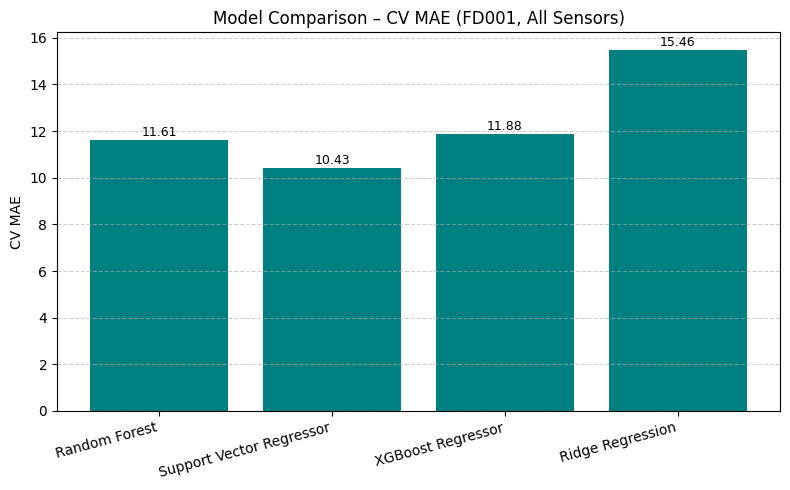

✅ R² Score comparison chart saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\model_comparison_cv_r2_fd001.png


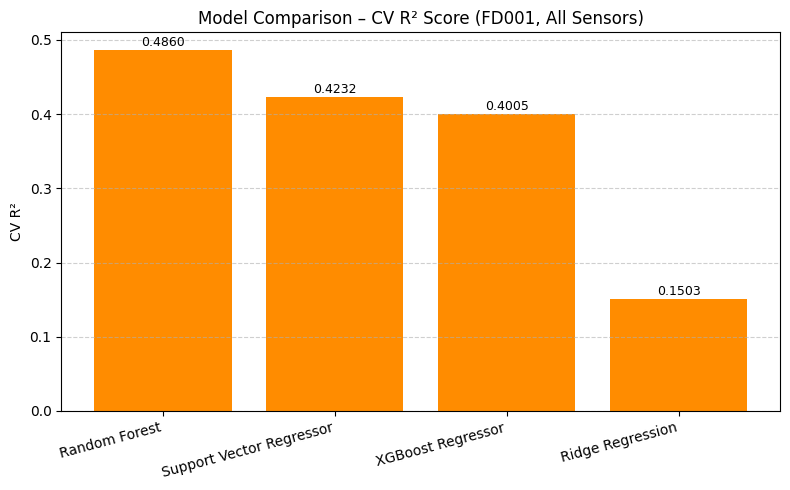

In [30]:
# ✅ MAE and R² Comparison Plots (FD001 – All Sensors)

import matplotlib.pyplot as plt
import os
import pandas as pd

# Load model_results if not already loaded
report_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'report', 'phase4'))
model_results_path = os.path.join(report_dir, 'model_comparison_cv_fd001.csv')
model_results = pd.read_csv(model_results_path)

# ==== MAE Comparison Plot ====
plt.figure(figsize=(8, 5))
bars = plt.bar(model_results['Model'], model_results['CV MAE (Mean)'], color='teal')
plt.title("Model Comparison – CV MAE (FD001, All Sensors)")
plt.ylabel("CV MAE")
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

# Save
fig_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4'))
os.makedirs(fig_dir, exist_ok=True)
mae_path = os.path.join(fig_dir, 'model_comparison_cv_mae_fd001.png')
plt.tight_layout()
plt.savefig(mae_path)
print(f"✅ MAE comparison chart saved to: {mae_path}")
plt.show()

# ==== R² Score Comparison Plot ====
plt.figure(figsize=(8, 5))
bars = plt.bar(model_results['Model'], model_results['CV R² (Mean)'], color='darkorange')
plt.title("Model Comparison – CV R² Score (FD001, All Sensors)")
plt.ylabel("CV R²")
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.4f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

# Save
r2_path = os.path.join(fig_dir, 'model_comparison_cv_r2_fd001.png')
plt.tight_layout()
plt.savefig(r2_path)
print(f"✅ R² Score comparison chart saved to: {r2_path}")
plt.show()


---
# Step 8: Residual Analysis – Ensemble and Individual Models (FD001)

✅ Saved residual distribution plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\residual_distribution_fd001.png


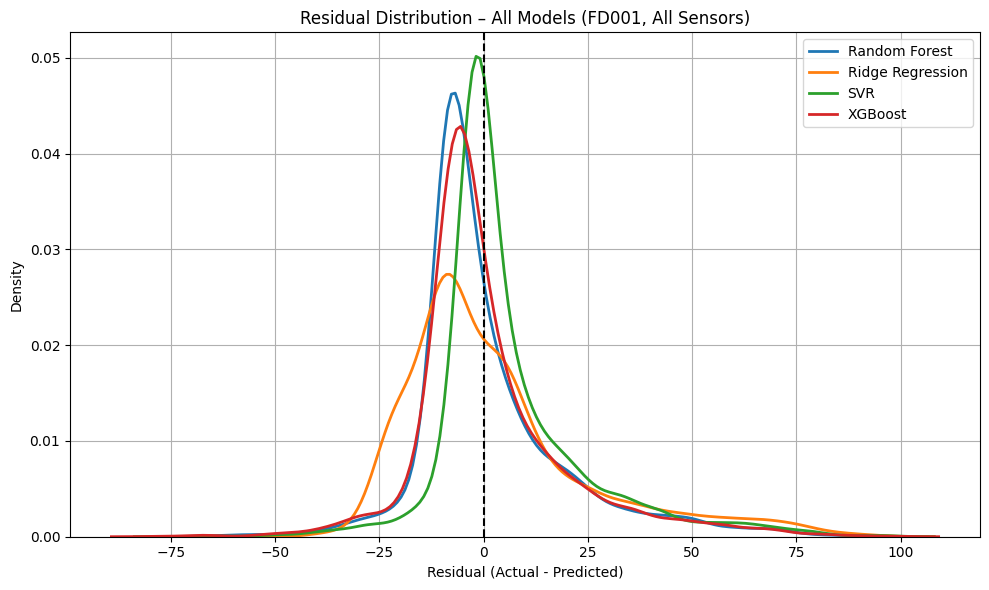

✅ Saved residual vs predicted plot to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\residual_vs_predicted_fd001.png


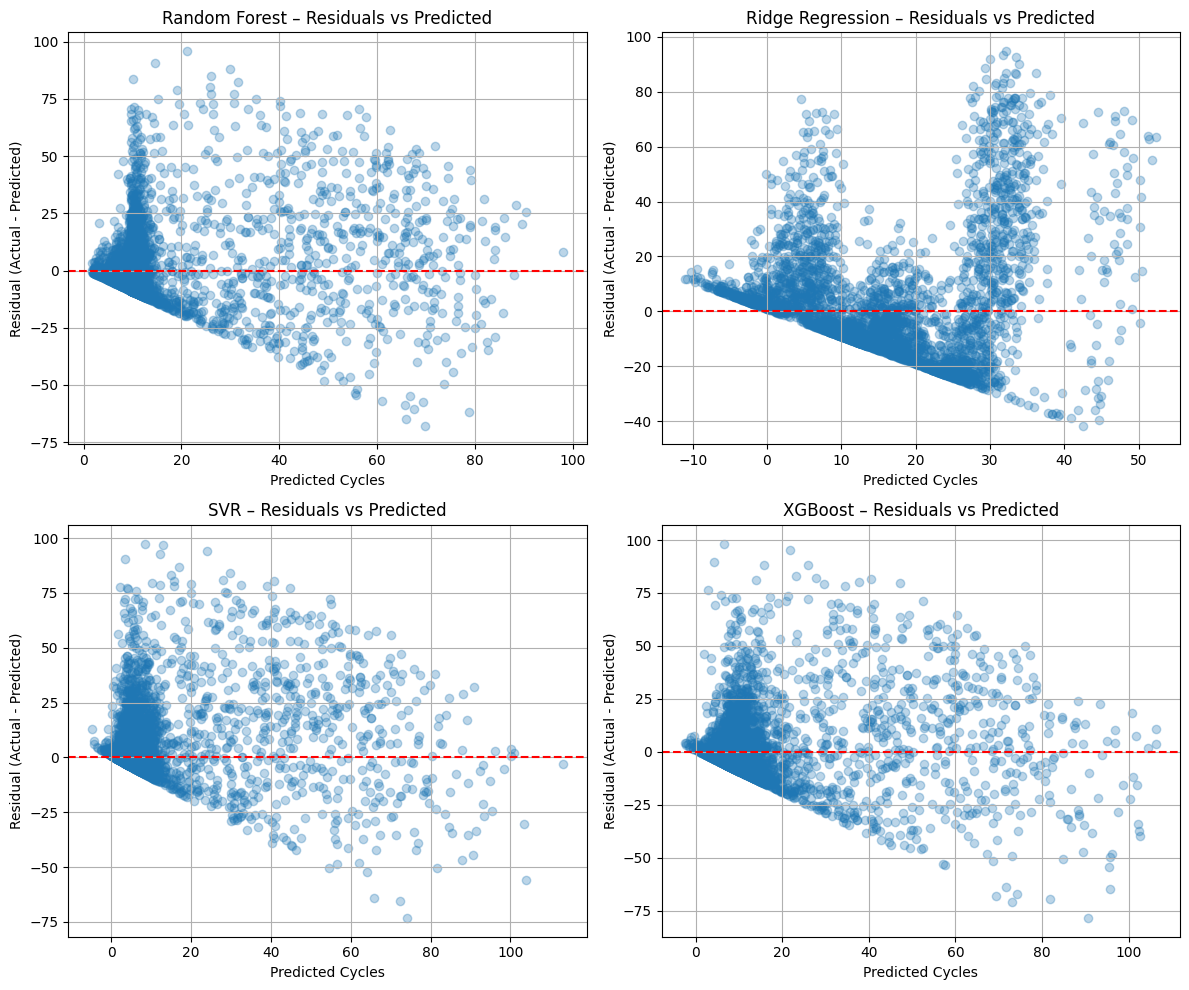

In [31]:
# ✅ Step 8: Residual Analysis for All Models (FD001 – All Sensors)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# === Step 8B: Compute Residuals ===
residuals = {
    "Random Forest": y_test - y_pred_rf,
    "Ridge Regression": y_test - y_pred_ridge,
    "SVR": y_test - y_pred_svr,
    "XGBoost": y_test - y_pred_xgb
}

# === Step 8C: Residual Distribution Plot ===
plt.figure(figsize=(10, 6))
for name, res in residuals.items():
    sns.kdeplot(res, label=name, linewidth=2)

plt.axvline(0, color='black', linestyle='--')
plt.title("Residual Distribution – All Models (FD001, All Sensors)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save plot
fig_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4'))
os.makedirs(fig_dir, exist_ok=True)
residual_dist_path = os.path.join(fig_dir, 'residual_distribution_fd001.png')
plt.savefig(residual_dist_path)
print(f"✅ Saved residual distribution plot to: {residual_dist_path}")
plt.show()

# === Step 8D: Residuals vs Predicted Plot for All Models ===
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

model_preds = {
    "Random Forest": y_pred_rf,
    "Ridge Regression": y_pred_ridge,
    "SVR": y_pred_svr,
    "XGBoost": y_pred_xgb
}

for ax, (name, pred) in zip(axes.flatten(), model_preds.items()):
    ax.scatter(pred, residuals[name], alpha=0.3)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title(f"{name} – Residuals vs Predicted")
    ax.set_xlabel("Predicted Cycles")
    ax.set_ylabel("Residual (Actual - Predicted)")
    ax.grid(True)

plt.tight_layout()
residual_vs_pred_path = os.path.join(fig_dir, 'residual_vs_predicted_fd001.png')
plt.savefig(residual_vs_pred_path)
print(f"✅ Saved residual vs predicted plot to: {residual_vs_pred_path}")
plt.show()


---

# Step 9: Ensemble Averaging – FD001


✅ Model Weights (based on inverse CV RMSE):
RF weight: 0.2670
RIDGE weight: 0.2157
SVR weight: 0.2596
XGB weight: 0.2577

✅ Weighted Ensemble Evaluation Metrics (FD001):
RMSE: 18.56
MAE : 12.34
R²  : 0.5072
✅ Ensemble prediction plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\weighted_ensemble_pred_vs_actual_fd001.png


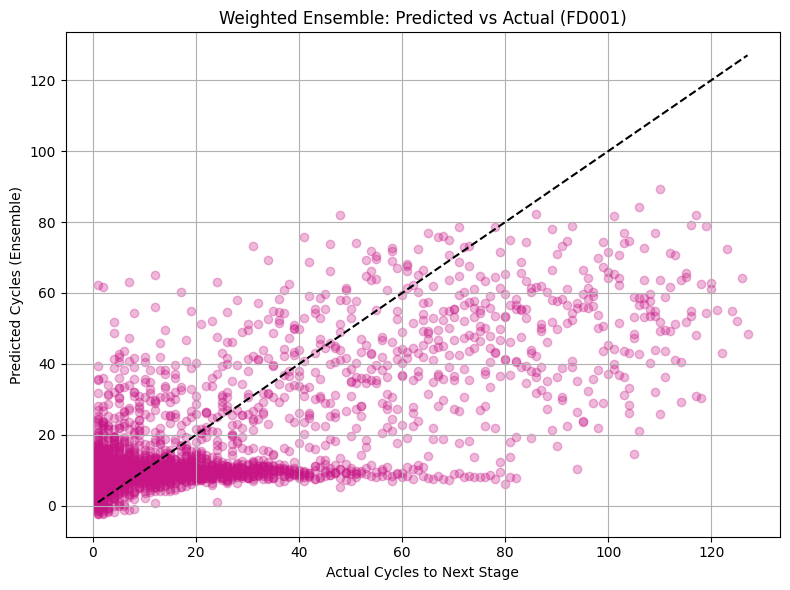

✅ Final CV + Ensemble comparison saved to: c:\Users\pandr\hybrid-predictive-maintenance\report\phase4\model_comparison_cv_with_ensemble_fd001.csv
                          Model  CV RMSE (Mean)  CV MAE (Mean)  CV R² (Mean)  \
0                 Random Forest       16.750000      11.610000      0.486000   
1      Support Vector Regressor       17.230000      10.430000      0.423200   
2             XGBoost Regressor       17.360000      11.880000      0.400500   
3  Weighted Ensemble (Inv RMSE)       18.559328      12.338398      0.507212   
4              Ridge Regression       20.740000      15.460000      0.150300   

   CV RMSE (± Std)  CV MAE (± Std)  CV R² (± Std)  
0             0.48            0.27         0.0160  
1             3.01            1.69         0.1080  
2             2.20            1.13         0.1351  
3              NaN             NaN            NaN  
4             2.55            1.22         0.1712  


In [32]:
# ✅ Step 9: Weighted Ensemble Averaging and Final Comparison Table (FD001 – All Sensors)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# === Step 9A & 9B: Weighted Ensemble Based on Inverse RMSE ===
rmse_values = {
    'rf': 16.75,     # Cross-validated RMSE
    'ridge': 20.74,
    'svr': 17.23,
    'xgb': 17.36
}

inverse_rmse = {k: 1/v for k, v in rmse_values.items()}
total_inverse = sum(inverse_rmse.values())
weights = {k: v / total_inverse for k, v in inverse_rmse.items()}

print("✅ Model Weights (based on inverse CV RMSE):")
for model, weight in weights.items():
    print(f"{model.upper()} weight: {weight:.4f}")

# Weighted predictions
y_pred_ensemble = (
    weights['rf'] * y_pred_rf +
    weights['ridge'] * y_pred_ridge +
    weights['svr'] * y_pred_svr +
    weights['xgb'] * y_pred_xgb
)

# === Step 9C: Evaluate Ensemble ===
rmse_ensemble = np.sqrt(mean_squared_error(y_test, y_pred_ensemble))
mae_ensemble = mean_absolute_error(y_test, y_pred_ensemble)
r2_ensemble = r2_score(y_test, y_pred_ensemble)

print("\n✅ Weighted Ensemble Evaluation Metrics (FD001):")
print(f"RMSE: {rmse_ensemble:.2f}")
print(f"MAE : {mae_ensemble:.2f}")
print(f"R²  : {r2_ensemble:.4f}")

# === Step 9D: Ensemble Predicted vs Actual Plot ===
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_ensemble, alpha=0.3, color='mediumvioletred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel("Actual Cycles to Next Stage")
plt.ylabel("Predicted Cycles (Ensemble)")
plt.title("Weighted Ensemble: Predicted vs Actual (FD001)")
plt.grid(True)
plt.tight_layout()

fig_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4'))
os.makedirs(fig_dir, exist_ok=True)
ensemble_plot_path = os.path.join(fig_dir, 'weighted_ensemble_pred_vs_actual_fd001.png')
plt.savefig(ensemble_plot_path)
print(f"✅ Ensemble prediction plot saved to: {ensemble_plot_path}")
plt.show()

# === Step 9E: Append to Comparison Table ===
report_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'report', 'phase4'))
cv_path = os.path.join(report_dir, 'model_comparison_cv_fd001.csv')
df_cv = pd.read_csv(cv_path)

ensemble_row = pd.DataFrame({
    'Model': ['Weighted Ensemble (Inv RMSE)'],
    'CV RMSE (Mean)': [rmse_ensemble],
    'CV MAE (Mean)': [mae_ensemble],
    'CV R² (Mean)': [r2_ensemble],
    'CV RMSE (± Std)': [np.nan],
    'CV MAE (± Std)': [np.nan],
    'CV R² (± Std)': [np.nan]
})

df_full = pd.concat([df_cv, ensemble_row], ignore_index=True)
df_full = df_full.sort_values(by='CV RMSE (Mean)').reset_index(drop=True)

full_path = os.path.join(report_dir, 'model_comparison_cv_with_ensemble_fd001.csv')
df_full.to_csv(full_path, index=False)

print(f"✅ Final CV + Ensemble comparison saved to: {full_path}")
print(df_full)


---

# Step 10 – Residual Analysis for Ensemble Averaging (FD001)


✅ Residual distribution plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\residual_distribution_weighted_ensemble_fd001.png


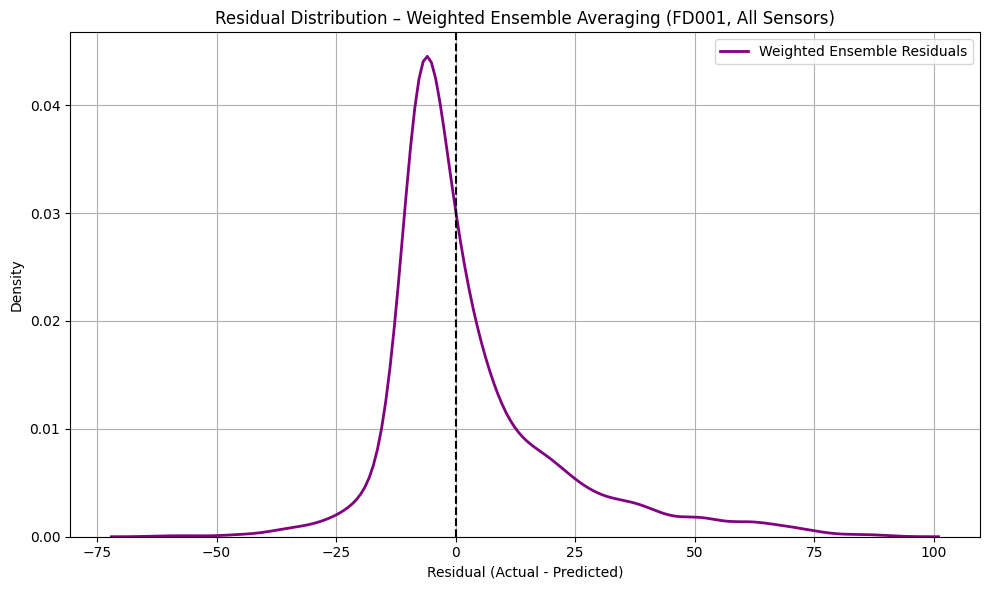

✅ Residual vs predicted plot saved to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4\residual_vs_predicted_weighted_ensemble_fd001.png


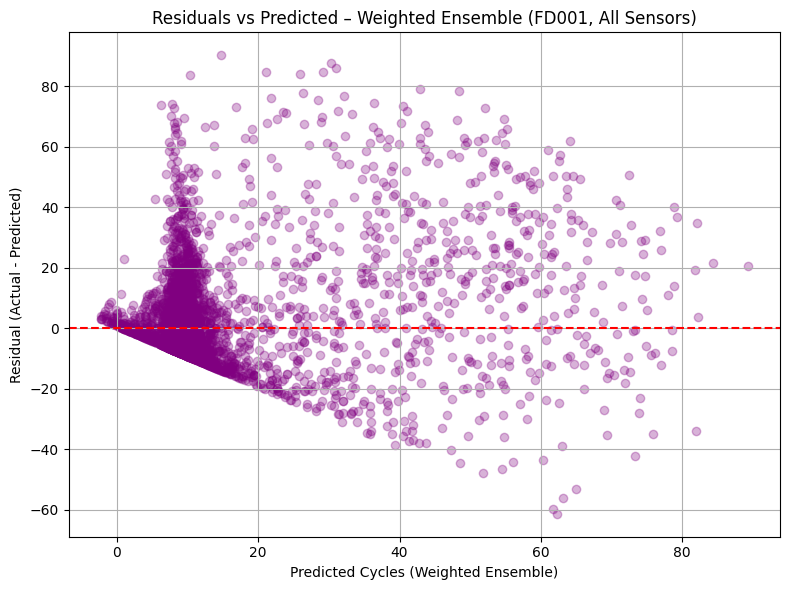

In [33]:
# ✅ Step 10 – Residual Analysis for Ensemble Averaging (FD001 – All Sensors)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# === Step 10A: Residual Distribution Plot for Ensemble ===
residuals_weighted_fd001 = y_test - y_pred_ensemble

plt.figure(figsize=(10, 6))
sns.kdeplot(residuals_weighted_fd001, color='purple', linewidth=2, label="Weighted Ensemble Residuals")
plt.axvline(0, linestyle='--', color='black')
plt.title("Residual Distribution – Weighted Ensemble Averaging (FD001, All Sensors)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save distribution plot
fig_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'figures', 'phase4'))
os.makedirs(fig_dir, exist_ok=True)
fig_path = os.path.join(fig_dir, 'residual_distribution_weighted_ensemble_fd001.png')
plt.savefig(fig_path)
print(f"✅ Residual distribution plot saved to: {fig_path}")
plt.show()

# === Step 10B: Residual vs Predicted Plot for Ensemble ===
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_ensemble, residuals_weighted_fd001, alpha=0.3, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Cycles (Weighted Ensemble)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted – Weighted Ensemble (FD001, All Sensors)")
plt.grid(True)
plt.tight_layout()

# Save residual vs predicted plot
fig_path2 = os.path.join(fig_dir, 'residual_vs_predicted_weighted_ensemble_fd001.png')
plt.savefig(fig_path2)
print(f"✅ Residual vs predicted plot saved to: {fig_path2}")
plt.show()


---

### Step 1–2: Load + Normalize Test Data (FD001)

In [35]:
# ✅ Step 1–2: Load and Normalize clean_test_FD001.csv using scaler_fd001.pkl

import pandas as pd
import numpy as np
import joblib
import os

# Define paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
TEST_FILE = os.path.join(BASE_DIR, 'data', 'clean_test_FD001.csv')
SCALER_PATH = os.path.join(BASE_DIR, 'models', 'scaler_fd001.pkl')  # ✅ fixed path

# Load test dataset
df_test = pd.read_csv(TEST_FILE)
print("✅ Loaded test dataset:", TEST_FILE)
print(df_test.head())

# Load saved scaler
scaler = joblib.load(SCALER_PATH)
print(f"✅ Loaded scaler from: {SCALER_PATH}")

# Identify sensor features
sensor_features = [col for col in df_test.columns if col.startswith('sensor_')]

# Normalize test sensor data
df_test[sensor_features] = scaler.transform(df_test[sensor_features])
print("✅ Applied MinMaxScaler normalization on sensor features")

# Preview normalized test data
print("\n🔍 Normalized test sample:")
print(df_test[sensor_features].head())


✅ Loaded test dataset: c:\Users\pandr\hybrid-predictive-maintenance\data\clean_test_FD001.csv
   unit  time  op_setting_1  op_setting_2  op_setting_3  sensor_2  sensor_3  \
0     1     1        0.0023        0.0003         100.0    643.02   1585.29   
1     1     2       -0.0027       -0.0003         100.0    641.71   1588.45   
2     1     3        0.0003        0.0001         100.0    642.46   1586.94   
3     1     4        0.0042        0.0000         100.0    642.44   1584.12   
4     1     5        0.0014        0.0000         100.0    642.51   1587.19   

   sensor_4  sensor_6  sensor_7  sensor_8  sensor_9  sensor_11  sensor_12  \
0   1398.21     21.61    553.90   2388.04   9050.17      47.20     521.72   
1   1395.42     21.61    554.85   2388.01   9054.42      47.50     522.16   
2   1401.34     21.61    554.11   2388.05   9056.96      47.50     521.97   
3   1406.42     21.61    554.07   2388.03   9045.29      47.28     521.38   
4   1401.92     21.61    554.16   2388.01   90

# # ✅ Step 3: Assign Clusters using Saved KMeans Model

In [36]:
    # ✅ Step 3: Assign Clusters using Saved KMeans Model

import joblib
import os

# Path to saved KMeans model
KMEANS_PATH = os.path.join(BASE_DIR, 'models', 'kmeans_model_fd001.pkl')

# Load the KMeans model
kmeans_model = joblib.load(KMEANS_PATH)
print(f"✅ Loaded KMeans model from: {KMEANS_PATH}")

# Predict cluster labels for test data
df_test['kmeans_cluster'] = kmeans_model.predict(df_test[sensor_features])
print("✅ Assigned clusters to test data")

# Show cluster counts
print("\n🔍 Cluster distribution in test data:")
print(df_test['kmeans_cluster'].value_counts())


✅ Loaded KMeans model from: c:\Users\pandr\hybrid-predictive-maintenance\models\kmeans_model_fd001.pkl
✅ Assigned clusters to test data

🔍 Cluster distribution in test data:
kmeans_cluster
2    13096
Name: count, dtype: int64


### ✅ Step 4: Map KMeans Clusters to Final Stages

In [38]:
# ✅ Step 4: Map KMeans Clusters to Final Stages

import json

# Path to saved cluster-to-stage map
MAP_PATH = os.path.join(BASE_DIR, 'models', 'cluster_to_stage_map_fd001.json')

# Load the mapping
with open(MAP_PATH, 'r') as f:
    cluster_to_stage_map = json.load(f)

print(f"✅ Loaded cluster-to-stage mapping from: {MAP_PATH}")
print("📘 Mapping:", cluster_to_stage_map)

# 🔧 Fix: Convert JSON keys from str to int
cluster_to_stage_map_int = {int(k): v for k, v in cluster_to_stage_map.items()}

# Apply corrected mapping
df_test['final_stage'] = df_test['kmeans_cluster'].map(cluster_to_stage_map_int)
print("✅ Corrected: Applied cluster-to-stage mapping with int keys")

# Preview
print(df_test[['unit', 'time', 'kmeans_cluster', 'final_stage']].head())



✅ Loaded cluster-to-stage mapping from: c:\Users\pandr\hybrid-predictive-maintenance\models\cluster_to_stage_map_fd001.json
📘 Mapping: {'2': 0, '3': 1, '0': 2, '4': 3, '1': 4}
✅ Corrected: Applied cluster-to-stage mapping with int keys
   unit  time  kmeans_cluster  final_stage
0     1     1               2            0
1     1     2               2            0
2     1     3               2            0
3     1     4               2            0
4     1     5               2            0


### Step 5: Test Predictions + Ensemble Output (FD001)

In [39]:
# ✅ Step 5: Predict on clean_test_FD001.csv using all regressors

import joblib
import os
import pandas as pd
import numpy as np

# Reload BASE_DIR if needed
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
MODEL_DIR = os.path.join(BASE_DIR, 'models', 'phase4')

# Paths to trained models
rf_model = joblib.load(os.path.join(MODEL_DIR, 'rf_regressor_fd001.pkl'))
ridge_model = joblib.load(os.path.join(MODEL_DIR, 'ridge_regressor_fd001.pkl'))
svr_model = joblib.load(os.path.join(MODEL_DIR, 'svr_regressor_fd001.pkl'))
xgb_model = joblib.load(os.path.join(MODEL_DIR, 'xgb_regressor_fd001.pkl'))

# Features used for prediction
sensor_features = [col for col in df_test.columns if col.startswith('sensor_')]

# Predict using each model
df_test['pred_rf'] = rf_model.predict(df_test[sensor_features])
df_test['pred_ridge'] = ridge_model.predict(df_test[sensor_features])
df_test['pred_svr'] = svr_model.predict(df_test[sensor_features])
df_test['pred_xgb'] = xgb_model.predict(df_test[sensor_features])

# Weighted Ensemble (Inverse RMSE Weights)
rmse_values = {'rf': 16.75, 'ridge': 20.74, 'svr': 17.23, 'xgb': 17.36}
inv_rmse = {k: 1/v for k, v in rmse_values.items()}
total_inv = sum(inv_rmse.values())
weights = {k: v / total_inv for k, v in inv_rmse.items()}

# Apply weighted ensemble
df_test['pred_ensemble'] = (
    weights['rf']   * df_test['pred_rf'] +
    weights['ridge'] * df_test['pred_ridge'] +
    weights['svr']   * df_test['pred_svr'] +
    weights['xgb']   * df_test['pred_xgb']
)

# ✅ Save test predictions
save_path = os.path.join(BASE_DIR, 'report', 'phase4', 'final_predictions_fd001_test.csv')
df_test[['unit', 'time', 'final_stage', 'pred_rf', 'pred_ridge', 'pred_svr', 'pred_xgb', 'pred_ensemble']].to_csv(save_path, index=False)
print(f"✅ Saved final test predictions to: {save_path}")


✅ Saved final test predictions to: c:\Users\pandr\hybrid-predictive-maintenance\report\phase4\final_predictions_fd001_test.csv


In [40]:
import matplotlib.pyplot as plt
import os

# Group by unit and plot ensemble prediction over time
units = df_test['unit'].unique()
fig_dir = os.path.join(BASE_DIR, 'figures', 'phase4')
os.makedirs(fig_dir, exist_ok=True)

for unit_id in units:
    df_engine = df_test[df_test['unit'] == unit_id]

    plt.figure(figsize=(8, 4))
    plt.plot(df_engine['time'], df_engine['pred_ensemble'], color='purple', label='Predicted Cycles to Next Stage')
    plt.title(f"Engine {unit_id} – Ensemble Prediction Over Time")
    plt.xlabel("Time (Cycles)")
    plt.ylabel("Predicted Cycles to Next Stage")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    # Save per-engine plot
    fig_path = os.path.join(fig_dir, f'ensemble_pred_engine_{unit_id:03d}_fd001.png')
    plt.savefig(fig_path)
    plt.close()

print(f"✅ Saved ensemble prediction trend plots for all engines to: {fig_dir}")


✅ Saved ensemble prediction trend plots for all engines to: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase4
